### 데이터 정제(clearning) - 이상치(anomaly, outlier)
1. 존재할 수 없는 값(성적 100점 만점에 125점)
2. 정상 범위에서 크게 벗어난 값(정상 범위 기준 필요)
- 이상값으로 인해 분석 결과가 왜곡되므로 처리 필요
- 이상값은 결측치로 만든 후에 처리

문제] 공부시간(hours)에 따른 성적(score) 데이터

조건) 성적은 0~100점 사이임


In [14]:
import pandas as pd
df = pd.DataFrame({
    'hours': [2, 4, 6, 8, 90],
    'score': [81, 93, 91,125, 98]
})
print(df)

   hours  score
0      2     81
1      4     93
2      6     91
3      8    125
4     90     98


In [15]:
print(df['score'] > 100) # score 열에서 100보다 큰 값이 있는지 확인
print((df['score'] > 100).sum()) # score 열에서 100보다 큰 값의 개수 계산
print(df[df['score'] > 100]['score'].count()) # score 열에서 100보다 큰 값이 있는 행을 필터링한 후, score 열의 개수 계산

0    False
1    False
2    False
3     True
4    False
Name: score, dtype: bool
1
1


In [17]:
import numpy as np
df['score'] = np.where(df['score'] > 100, np.nan, df['score']) # score 열에서 100보다 큰 값을 결측치로 대체
print(df)

   hours  score
0      2   81.0
1      4   93.0
2      6   91.0
3      8    NaN
4     90   98.0


In [13]:
# 데이터프레임 where() 메서드 사용
df['score'] = df['score'].where(df['score'] <= 100, None) # score 열에서 100보다 큰 값을 None으로 대체
print(df)

   hours  score
0      2  81.00
1      4  93.00
2      6  91.00
3      8  90.75
4     90  98.00


In [12]:
# 인덱스 
df.loc[df['score'] > 100, 'score'] = None # score 열에서 100보다 큰 값을 None으로 대체
print(df)

   hours  score
0      2  81.00
1      4  93.00
2      6  91.00
3      8  90.75
4     90  98.00


In [8]:
# 1. 삭제 
df1 = df.dropna(subset=['score']) # score 열에서 결측치가 있는 행을 제거한 새로운 데이터프레임 생성
print(df1) 

   hours  score
0      2   81.0
1      4   93.0
2      6   91.0
4     90   98.0


In [9]:
# 2. 평균으로 채움
df['score'] = df['score'].fillna(df['score'].mean()) # score 열에서 결측치를 score 열의 평균값으로 대체
print(df)

   hours  score
0      2  81.00
1      4  93.00
2      6  91.00
3      8  90.75
4     90  98.00


In [18]:
# 3. 이전값으로 채움
df['score'] = df['score'].ffill() # score 열에서 결측치를 이전 행의 값으로 대체
print(df)

   hours  score
0      2   81.0
1      4   93.0
2      6   91.0
3      8   91.0
4     90   98.0


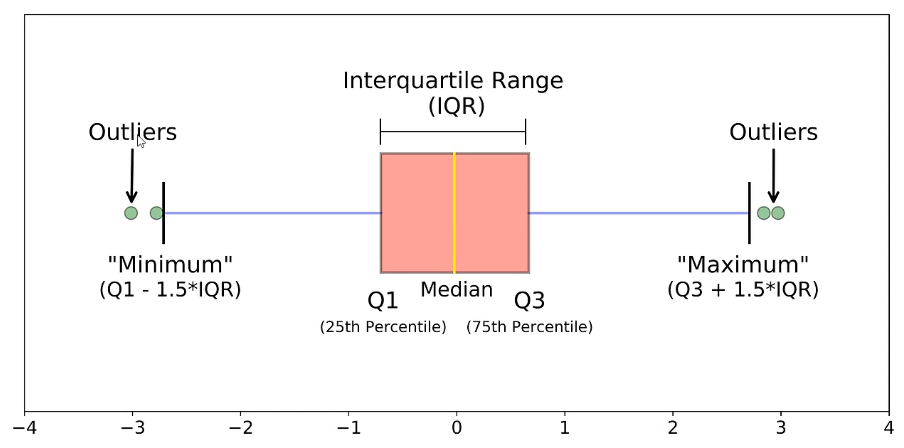

In [6]:
import pandas as pd
df = pd.DataFrame({
    'hours': [2, 4, 6, 8, 90],
    'score': [81, 93, 91,125, 98]
})
print(df)

   hours  score
0      2     81
1      4     93
2      6     91
3      8    125
4     90     98


In [7]:
pct25 = df['hours'].quantile(0.25) # hours 열의 25% 분위수 계산
pct75 = df['hours'].quantile(0.75) # hours 열의 75% 분위수 계산
iqr = pct75 - pct25 # IQR 계산
lower_bound = pct25 - 1.5 * iqr # 하한 계산
upper_bound = pct75 + 1.5 * iqr # 상한 계산
print(f"25% 분위수: {pct25}, 75% 분위수: {pct75}, IQR: {iqr}, 하한: {lower_bound}, 상한: {upper_bound}")

25% 분위수: 4.0, 75% 분위수: 8.0, IQR: 4.0, 하한: -2.0, 상한: 14.0


In [8]:
import numpy as np
df['hours'] = np.where((df['hours'] < lower_bound) | (df['hours'] > upper_bound), np.nan, df['hours']) # hours 열에서 하한보다 작거나 상한보다 큰 값을 결측치로 대체
print(df)
df['score'] = np.where(df['score'] > 100, np.nan, df['score']) # score 열에서 100보다 큰 값을 결측치로 대체
print(df)

   hours  score
0    2.0     81
1    4.0     93
2    6.0     91
3    8.0    125
4    NaN     98
   hours  score
0    2.0   81.0
1    4.0   93.0
2    6.0   91.0
3    8.0    NaN
4    NaN   98.0


In [9]:
# 1. 삭제
df1 = df.dropna(subset=['hours', 'score']) # hours 또는 score 열에서 결측치가 있는 행을 제거한 새로운 데이터프레임 생성
print(df1)

   hours  score
0    2.0   81.0
1    4.0   93.0
2    6.0   91.0


In [10]:
# 2. 평균으로 채움
df['hours'] = df['hours'].fillna(df['hours'].mean()) # hours 열에서 결측치를 hours 열의 평균값으로 대체
df['score'] = df['score'].fillna(df['score'].mean()) # score 열에서 결측치를 score 열의 평균값으로 대체
print(df)

   hours  score
0    2.0  81.00
1    4.0  93.00
2    6.0  91.00
3    8.0  90.75
4    5.0  98.00
